# End-To-End Memory Networks (MemN2N)

This notebook implements the **End-To-End Memory Networks** architecture proposed by Sukhbaatar et al. (2015). We cover two tasks:

1. **Synthetic Question Answering** on the bAbI dataset

The key idea is a recurrent attention mechanism over an external memory, trained fully end-to-end via backpropagation unlike the original Memory Networks which required supervision at each layer.

---

## 1. Setup and Dependencies

In [10]:
import os
import math
import urllib
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm.auto import tqdm
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import tarfile

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

def _get_device():
    if not torch.cuda.is_available():
        return torch.device('cpu')
    try:
        torch.zeros(1).cuda()
        return torch.device('cuda')
    except Exception:
        return torch.device('cpu')

DEVICE = _get_device()
print(f'Using device: {DEVICE}')

Using device: cpu


---
## Data Loading bAbI

The bAbI dataset consists of 20 synthetic QA tasks, each designed to test a specific type of reasoning (e.g., path finding, coreference, counting). Each sample is a list of sentences (the story), a question, and a single-word answer.

In [11]:
# Download bAbI dataset if not already present
BABI_URL = 'https://s3.amazonaws.com/text-datasets/babi_tasks_1-20_v1-2.tar.gz'
BASE_DIR = '/kaggle/working' if os.path.exists('/kaggle/working') else '../'
BABI_DIR = os.path.join(BASE_DIR, 'babi_data')


is_data_downloaded = os.path.exists(os.path.join(BABI_DIR, 'tasks_1-20_v1-2', 'en-10k'))
if not is_data_downloaded:
    print('Downloading bAbI dataset...')
    os.makedirs(BABI_DIR, exist_ok=True)
    tar_path = os.path.join(BASE_DIR, 'babi.tar.gz')
    urllib.request.urlretrieve(BABI_URL, tar_path)
    with tarfile.open(tar_path) as f:
        f.extractall(BABI_DIR)
    os.remove(tar_path)
    print('Done.')
else:
    print('bAbI data already downloaded.')

bAbI data already downloaded.


---
## 2. Dataset Analysis

Before building anything, it's worth spending a few minutes actually looking at the data. The bAbI dataset has 20 tasks — each one tests a different kind of reasoning. Here we'll get a feel for the scale, structure, and what the model is actually being asked to do.

In [12]:
data_dir = os.path.join(BABI_DIR, 'tasks_1-20_v1-2', 'en-10k')

TASK_NAMES = {
    1: 'single-supporting-fact', 2: 'two-supporting-facts',
    3: 'three-supporting-facts', 4: 'two-arg-relations',
    5: 'three-arg-relations',    6: 'yes-no-questions',
    7: 'counting',               8: 'lists-sets',
    9: 'simple-negation',        10: 'indefinite-knowledge',
    11: 'basic-coreference',     12: 'conjunction',
    13: 'compound-coreference',  14: 'time-reasoning',
    15: 'basic-deduction',       16: 'basic-induction',
    17: 'positional-reasoning',  18: 'size-reasoning',
    19: 'path-finding',          20: 'agents-motivations'
}

def parse_task(path):
    stories, story_lens, answers = 0, [], []
    cur_len = 0
    with open(path) as f:
        for line in f:
            idx = int(line.strip().split(' ', 1)[0])
            if idx == 1 and cur_len > 0:
                story_lens.append(cur_len); cur_len = 0; stories += 1
            cur_len += 1
            if '\t' in line:
                answers.append(line.strip().split('\t')[1].strip().lower())
    if cur_len: story_lens.append(cur_len); stories += 1
    return stories, story_lens, answers

stats = {}
for tid in range(1, 21):
    tr = [f for f in os.listdir(data_dir) if f.startswith('qa%d_' % tid) and 'train' in f][0]
    te = [f for f in os.listdir(data_dir) if f.startswith('qa%d_' % tid) and 'test'  in f][0]
    tr_s, tr_lens, tr_ans = parse_task(os.path.join(data_dir, tr))
    te_s, te_lens, te_ans = parse_task(os.path.join(data_dir, te))
    stats[tid] = dict(
        name=TASK_NAMES[tid], tr_stories=tr_s, te_stories=te_s,
        tr_qa=len(tr_ans), avg_story_len=round(sum(tr_lens)/len(tr_lens), 1),
        unique_ans=len(set(tr_ans + te_ans)), answers=tr_ans + te_ans
    )

total_train_qa = sum(s['tr_qa'] for s in stats.values())
total_words = sum(
    len(line.split()) for fname in os.listdir(data_dir)
    if fname.endswith('.txt')
    for line in open(os.path.join(data_dir, fname))
)

print("=== bAbI Dataset — Quick Overview ===\n")
print(f"20 tasks, each testing a different reasoning skill")
print(f"{total_train_qa:,} training QA pairs in total (10k per task)")
print(f"~{total_words:,} total word tokens across all files")
print(f"Vocabulary: only ~145 unique words — intentionally tiny")
print()

# Hardest tasks by average story length
sorted_by_len = sorted(stats.items(), key=lambda x: x[1]['avg_story_len'], reverse=True)
print("Tasks with the longest stories (most context to remember):")
for tid, s in sorted_by_len[:5]:
    print(f"Task {tid:>2} ({s['name']:<28}) avg {s['avg_story_len']:>5} lines/story")

print()
print("Tasks with the smallest answer space (almost binary):")
for tid, s in stats.items():
    if s['unique_ans'] <= 2:
        print(f"Task {tid:>2} ({s['name']:<28}) only {s['unique_ans']} possible answers")


=== bAbI Dataset — Quick Overview ===

20 tasks, each testing a different reasoning skill
200,000 training QA pairs in total (10k per task)
~6,658,468 total word tokens across all files
Vocabulary: only ~145 unique words — intentionally tiny

Tasks with the longest stories (most context to remember):
Task  3 (three-supporting-facts      ) avg  79.4 lines/story
Task  5 (three-arg-relations         ) avg  32.3 lines/story
Task  2 (two-supporting-facts        ) avg  27.0 lines/story
Task 20 (agents-motivations          ) avg  21.4 lines/story
Task  8 (lists-sets                  ) avg  18.3 lines/story

Tasks with the smallest answer space (almost binary):
Task  6 (yes-no-questions            ) only 2 possible answers
Task  9 (simple-negation             ) only 2 possible answers
Task 17 (positional-reasoning        ) only 2 possible answers
Task 18 (size-reasoning              ) only 2 possible answers


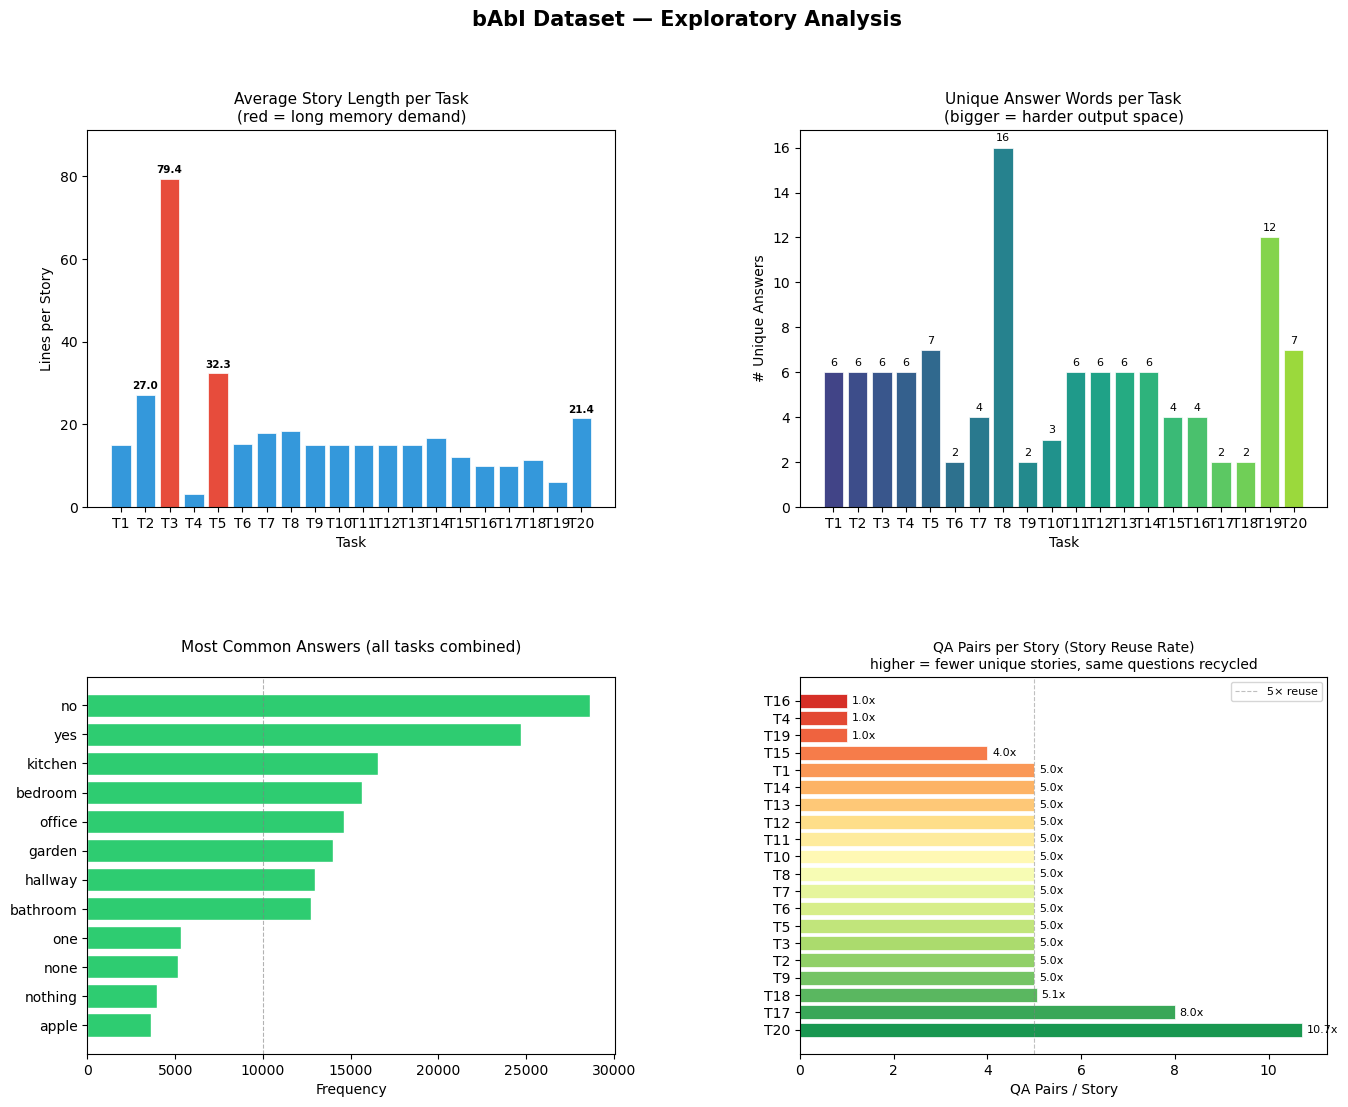

Figure saved to babi_analysis.png


In [13]:
fig = plt.figure(figsize=(16, 12))
fig.suptitle('bAbI Dataset — Exploratory Analysis', fontsize=15, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

task_ids    = list(range(1, 21))
task_labels = ['T%d' % i for i in task_ids]
avg_lens    = [stats[i]['avg_story_len'] for i in task_ids]
unique_ans  = [stats[i]['unique_ans']    for i in task_ids]

# ── 1. Average story length per task ──────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
colors = ['#e74c3c' if l > 30 else '#3498db' for l in avg_lens]
bars = ax1.bar(task_labels, avg_lens, color=colors, edgecolor='white', linewidth=0.5)
ax1.set_title('Average Story Length per Task\n(red = long memory demand)', fontsize=11)
ax1.set_xlabel('Task'); ax1.set_ylabel('Lines per Story')
ax1.set_ylim(0, max(avg_lens) * 1.15)
for bar, v in zip(bars, avg_lens):
    if v > 20:
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 str(v), ha='center', va='bottom', fontsize=7.5, fontweight='bold')

# ── 2. Answer vocabulary size per task ────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
palette = plt.cm.viridis(np.linspace(0.2, 0.85, len(task_ids)))
ax2.bar(task_labels, unique_ans, color=palette, edgecolor='white', linewidth=0.5)
ax2.set_title('Unique Answer Words per Task\n(bigger = harder output space)', fontsize=11)
ax2.set_xlabel('Task'); ax2.set_ylabel('# Unique Answers')
for i, v in enumerate(unique_ans):
    ax2.text(i, v + 0.2, str(v), ha='center', va='bottom', fontsize=8)

# ── 3. Global answer frequency (top 12) ───────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
all_answers = [a for s in stats.values() for a in s['answers']]
top_ans = Counter(all_answers).most_common(12)
words, cnts = zip(*top_ans)
ax3.barh(list(reversed(words)), list(reversed(cnts)), color='#2ecc71', edgecolor='white')
ax3.set_title('Most Common Answers (all tasks combined)\n', fontsize=11)
ax3.set_xlabel('Frequency')
ax3.axvline(x=10000, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

# ── 4. QA pairs per story (story reuse rate) ─────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
tr_stories = [stats[i]['tr_stories'] for i in task_ids]
tr_qa      = [stats[i]['tr_qa']      for i in task_ids]
qa_per_story = [q / s for q, s in zip(tr_qa, tr_stories)]

cmap_vals = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(task_ids)))
sorted_idx = np.argsort(qa_per_story)[::-1]
sorted_labels = [task_labels[i] for i in sorted_idx]
sorted_vals   = [qa_per_story[i] for i in sorted_idx]
sorted_colors = [cmap_vals[rank] for rank, _ in enumerate(sorted_idx)]

h_bars = ax4.barh(sorted_labels, sorted_vals, color=sorted_colors, edgecolor='white', linewidth=0.5)
ax4.set_title('QA Pairs per Story (Story Reuse Rate)\nhigher = fewer unique stories, same questions recycled', fontsize=10)
ax4.set_xlabel('QA Pairs / Story')
ax4.axvline(x=5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5, label='5× reuse')
ax4.legend(fontsize=8)
for bar, v in zip(h_bars, sorted_vals):
    ax4.text(v + 0.1, bar.get_y() + bar.get_height()/2,
             '%.1fx' % v, va='center', fontsize=8)

plt.savefig('../images/babi_analysis.png', dpi=130, bbox_inches='tight')
plt.show()
print("Figure saved to babi_analysis.png")


### What the data is telling us

First thing that jumps out the vocabulary is only ~145 words. That's not a typo. This dataset was never meant to test whether a model understands language; it's testing whether it can reason over it. The words are simple. The logic isn't.

Story length is probably the most honest measure of difficulty here. Most tasks sit around 15 lines, which is manageable. Task 3 though? Average of 79 lines per story. The model has to read through all of that, figure out which three sentences actually matter, and ignore the rest. That's where a lot of memory architectures quietly fall apart.

Something that's easy to miss: every task has exactly 10k QA pairs, but the number of actual stories behind them is all over the place. Task 20 only has 933 unique stories so those same stories are being asked about roughly 10 different times each. A model that just memorizes the templates will look fine on paper but hasn't really learned anything.

On the answer side, tasks 6, 9, 17, and 18 only have two possible answers. Yes/no, left/right. Random guessing already gets you 50% there, so high accuracy on those doesn't say much. Task 8 is the opposite, it has 16 unique answers and that's where you'd actually expect a weaker model to struggle.

The location words (kitchen, bedroom, office, garden) absolutely dominate the answer distribution across all tasks combined. Makes sense given how many tasks are about tracking where people go, but it's worth knowing in case you're looking at aggregate stats and wondering why the model seems biased toward place names.